In [1]:
"""
scRNA-seq Label Transfer Script
================================
Transfers cell type labels from a reference dataset to a query dataset
using Seurat-style anchor-based integration via scanpy/scvi or
a k-NN weighted approach with scanorama/harmony embeddings.

Methods supported:
  1. KNN-based (default) - fast, uses PCA + cosine similarity
  2. Harmony-based       - batch-corrected embedding before KNN
  3. Seurat-style        - mutual nearest neighbors (MNN) anchors

Requirements:
    pip install scanpy anndata scikit-learn harmonypy scanorama
"""

import argparse
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import anndata as ad
import os


# ─────────────────────────────────────────────
# I/O helpers
# ─────────────────────────────────────────────

def load_adata(path: str) -> ad.AnnData:
    """Load AnnData from .h5ad, .loom, or 10x directory."""
    if path.endswith(".h5ad"):
        return sc.read_h5ad(path)
    elif path.endswith(".loom"):
        return sc.read_loom(path)
    elif path.endswith(".csv"):
        return sc.read_csv(path).T
    else:
        # Assume 10x Genomics directory
        return sc.read_10x_mtx(path, var_names="gene_symbols", cache=True)


def save_adata(adata: ad.AnnData, path: str):
    adata.write_h5ad(path)
    print(f"  Saved → {path}")


# ─────────────────────────────────────────────
# Preprocessing
# ─────────────────────────────────────────────

def preprocess(adata: ad.AnnData, n_top_genes: int = 2000,
               n_pcs: int = 50, name: str = "") -> ad.AnnData:
    """Standard scanpy preprocessing pipeline."""
    print(f"\n[Preprocess] {name}  shape={adata.shape}")
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)

    # Normalise & log
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    # HVG
    sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, flavor="cell_ranger", # _v3",
                                 span=0.3)
    adata.raw = adata  # store raw for DE later

    adata = adata[:, adata.var.highly_variable].copy()

    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, n_comps=n_pcs, svd_solver="arpack")

    print(f"  → {adata.shape[0]} cells  |  {adata.shape[1]} HVGs  |  {n_pcs} PCs")
    return adata


# ─────────────────────────────────────────────
# Label transfer methods
# ─────────────────────────────────────────────

def find_common_genes(ref: ad.AnnData, query: ad.AnnData):
    common = list(set(ref.var_names) & set(query.var_names))
    print(f"  Common genes: {len(common)}")
    if len(common) < 100:
        raise ValueError("Too few common genes – check gene naming conventions.")
    return ref[:, common].copy(), query[:, common].copy()


# ── Method 1: KNN on shared PCA ──────────────

def transfer_knn(ref: ad.AnnData, query: ad.AnnData,
                 label_key: str, k: int = 15,
                 n_pcs: int = 30) -> pd.Series:
    """
    Simple KNN label transfer in a shared PCA space.
    Both datasets are concatenated → joint PCA → split back.
    """
    print("\n[Method: KNN] building shared PCA embedding …")

    ref2, query2 = find_common_genes(ref, query)

    # Concatenate for joint PCA
    ref2.obs["_split"] = "reference"
    query2.obs["_split"] = "query"
    combined = ad.concat([ref2, query2], label="_batch",
                         keys=["ref", "query"], join="inner")

    sc.pp.scale(combined, max_value=10)
    sc.tl.pca(combined, n_comps=n_pcs, svd_solver="arpack")

    ref_idx  = combined.obs["_split"] == "reference"
    query_idx = combined.obs["_split"] == "query"

    X_ref   = combined[ref_idx].obsm["X_pca"]
    X_query = combined[query_idx].obsm["X_pca"]
    y_ref   = ref.obs[label_key].values

    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine",
                                weights="distance", n_jobs=-1)
    knn.fit(X_ref, y_ref)

    predicted = knn.predict(X_query)
    proba     = knn.predict_proba(X_query)
    confidence = proba.max(axis=1)

    labels = pd.Series(predicted, index=query.obs_names, name="predicted_label")
    conf   = pd.Series(confidence, index=query.obs_names, name="prediction_score")
    return labels, conf, knn.classes_


# ── Method 2: Harmony-corrected KNN ──────────

def transfer_harmony(ref: ad.AnnData, query: ad.AnnData,
                     label_key: str, k: int = 15,
                     n_pcs: int = 30) -> pd.Series:
    """KNN after Harmony batch correction."""
    try:
        import harmonypy as hm
    except ImportError:
        raise ImportError("Install harmonypy:  pip install harmonypy")

    print("\n[Method: Harmony] correcting batch effect …")

    ref2, query2 = find_common_genes(ref, query)
    ref2.obs["_split"] = "reference"
    query2.obs["_split"] = "query"
    combined = ad.concat([ref2, query2], label="_batch",
                         keys=["ref", "query"], join="inner")

    sc.pp.scale(combined, max_value=10)
    sc.tl.pca(combined, n_comps=n_pcs, svd_solver="arpack")

    ho = hm.run_harmony(combined.obsm["X_pca"],
                        combined.obs, "_batch",
                        max_iter_harmony=20, random_state=42)
    combined.obsm["X_harmony"] = ho.Z_corr.T

    ref_idx   = combined.obs["_split"] == "reference"
    query_idx = combined.obs["_split"] == "query"

    X_ref   = combined[ref_idx].obsm["X_harmony"]
    X_query = combined[query_idx].obsm["X_harmony"]
    y_ref   = ref.obs[label_key].values

    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine",
                                weights="distance", n_jobs=-1)
    knn.fit(X_ref, y_ref)

    predicted  = knn.predict(X_query)
    confidence = knn.predict_proba(X_query).max(axis=1)

    labels = pd.Series(predicted, index=query.obs_names, name="predicted_label")
    conf   = pd.Series(confidence, index=query.obs_names, name="prediction_score")
    return labels, conf, knn.classes_


# ── Method 3: MNN anchors (Seurat-like) ──────

def transfer_mnn(ref: ad.AnnData, query: ad.AnnData,
                 label_key: str, k: int = 5,
                 k_weight: int = 100, n_pcs: int = 30) -> pd.Series:
    """
    Mutual Nearest Neighbor anchor-based label transfer
    (simplified Seurat TransferData logic in Python).
    """
    print("\n[Method: MNN Anchors] finding mutual nearest neighbors …")

    ref2, query2 = find_common_genes(ref, query)
    sc.pp.scale(ref2,   max_value=10)
    sc.pp.scale(query2, max_value=10)
    sc.tl.pca(ref2,   n_comps=n_pcs, svd_solver="arpack")
    sc.tl.pca(query2, n_comps=n_pcs, svd_solver="arpack")

    from sklearn.neighbors import NearestNeighbors

    # Build KNN graphs
    nn_ref   = NearestNeighbors(n_neighbors=k, metric="cosine").fit(ref2.obsm["X_pca"])
    nn_query = NearestNeighbors(n_neighbors=k, metric="cosine").fit(query2.obsm["X_pca"])

    # ref → query neighbours
    dist_rq, idx_rq = nn_query.kneighbors(ref2.obsm["X_pca"])
    # query → ref neighbours
    dist_qr, idx_qr = nn_ref.kneighbors(query2.obsm["X_pca"])

    # Find mutual pairs (anchors)
    anchors = []
    for r_i, (q_neighbors, _) in enumerate(zip(idx_rq, dist_rq)):
        for q_j in q_neighbors:
            if r_i in idx_qr[q_j]:
                anchors.append((r_i, q_j))

    print(f"  Found {len(anchors)} MNN anchors")

    if len(anchors) < 10:
        print("  ⚠  Very few anchors – falling back to KNN method")
        return transfer_knn(ref, query, label_key, k=k_weight, n_pcs=n_pcs)

    # Weighted label transfer from anchors
    nn_anchors = NearestNeighbors(n_neighbors=min(k_weight, len(anchors)),
                                  metric="cosine")
    anchor_ref_pcs = ref2.obsm["X_pca"][[a[0] for a in anchors]]
    nn_anchors.fit(anchor_ref_pcs)

    dists, idxs = nn_anchors.kneighbors(query2.obsm["X_pca"])
    weights = np.exp(-dists)          # softmax-style weighting
    weights /= weights.sum(axis=1, keepdims=True)

    anchor_labels = np.array([ref.obs[label_key].iloc[anchors[i][0]] for i in range(len(anchors))])
    le = LabelEncoder().fit(anchor_labels)
    anchor_codes = le.transform(anchor_labels)

    # Weighted vote
    predicted, confidence = [], []
    for w, idx in zip(weights, idxs):
        vote = np.zeros(len(le.classes_))
        for wi, ai in zip(w, idx):
            vote[anchor_codes[ai]] += wi
        predicted.append(le.classes_[vote.argmax()])
        confidence.append(vote.max())

    labels = pd.Series(predicted,  index=query.obs_names, name="predicted_label")
    conf   = pd.Series(confidence, index=query.obs_names, name="prediction_score")
    return labels, conf, le.classes_


# ─────────────────────────────────────────────
# Post-processing & output
# ─────────────────────────────────────────────

def add_predictions_to_query(query: ad.AnnData,
                             labels: pd.Series,
                             conf: pd.Series,
                             tag: str = "") -> ad.AnnData:
    query.obs[f"predicted_label_{tag}"]  = labels.values
    query.obs[f"prediction_score_{tag}"] = conf.values
    query.obs[f"high_confidence_{tag}"]  = conf.values >= 0.5
    return query


def print_summary(query: ad.AnnData, label_key: str = None):
    print("\n── Label transfer summary ──────────────────")
    vc = query.obs["predicted_label"].value_counts()
    print(vc.to_string())

    if label_key and label_key in query.obs.columns:
        print("\n── Classification report (ground truth vs predicted) ──")
        print(classification_report(query.obs[label_key],
                                    query.obs["predicted_label"],
                                    zero_division=0))

    mean_conf = query.obs["prediction_score"].mean()
    pct_high  = (query.obs["high_confidence"]).mean() * 100
    print(f"\n  Mean confidence score : {mean_conf:.3f}")
    print(f"  High-confidence cells : {pct_high:.1f}%")


def export_labels_csv(query: ad.AnnData, out_csv: str):
    df = query.obs[["predicted_label", "prediction_score", "high_confidence"]].copy()
    df.to_csv(out_csv)
    print(f"  Labels exported → {out_csv}")


# ─────────────────────────────────────────────
# Programmatic API (import as module)
# ─────────────────────────────────────────────

def transfer_labels(ref: ad.AnnData,
                    query: ad.AnnData,
                    label_key: str,
                    method: str = "knn",
                    k: int = 15,
                    n_pcs: int = 30,
                    n_hvg: int = 2000) -> ad.AnnData:
    """
    Convenience function for use in notebooks / pipelines.

    Example
    -------
    >>> from label_transfer_scrna import transfer_labels
    >>> query = transfer_labels("ref.h5ad", "query.h5ad", label_key="cell_type")
    >>> query.obs[["predicted_label", "prediction_score"]].head()
    """
    # ref   = load_adata(ref_path)
    # query = load_adata(query_path)

    # ref   = preprocess(ref,   n_top_genes=n_hvg, n_pcs=n_pcs, name="reference")
    # query = preprocess(query, n_top_genes=n_hvg, n_pcs=n_pcs, name="query")

    dispatch = {"knn": transfer_knn, "harmony": transfer_harmony, "mnn": transfer_mnn}
    labels, conf, _ = dispatch[method](ref, query, label_key=label_key,
                                       k=k, n_pcs=n_pcs)
    query_updated = add_predictions_to_query(query, labels, conf, tag=method)
     
    return labels, conf, query_updated


In [2]:
ddir = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/'

In [3]:
%%time
f = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/allen_dev_v1/DevVIS_multiome_snRNA_processed_it_adult.h5ad'
adata = sc.read(f)
adata = adata[adata.obs['subclass_label']=='L2/3 IT CTX Glut']
adata = adata[adata.obs['age_label'].isin(['P56'])]
adata

CPU times: user 0 ns, sys: 3.49 s, total: 3.49 s
Wall time: 1min 23s


View of AnnData object with n_obs × n_vars = 6364 × 7100
    obs: 'Unnamed: 0', 'subcluster_id', 'subcluster_label', 'cluster_label', 'subclass_label', 'class_label', 'subcluster_prob', 'cluster_probability', 'subclass_probability', 'class_probability', 'library_prep', 'roi', 'sex', 'donor_name', 'age_label', 'cellNames'
    obsm: 'pca_later'
    layers: 'lognorm', 'norm', 'zlognorm'

In [4]:
adata.X.data

array([39,  1,  1, ...,  1,  3,  3], dtype=int32)

In [5]:
%%time
f = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/allen_human_v1/Jorstad_processed.h5ad'
adata2 = sc.read(f)
# adata2 = adata2[adata2.obs['Subclass']=='L2/3'].copy()
# adata2 = adata2[adata2.obs['Age'].isin(['P21', 'P21DR'])].copy()
adata2

CPU times: user 411 ms, sys: 2.63 s, total: 3.04 s
Wall time: 1min 5s


AnnData object with n_obs × n_vars = 54742 × 2703
    obs: 'Class', 'CrossArea_subclass', 'CrossArea_cluster', 'WithinArea_subclass', 'WithinArea_cluster', 'Source', 'Layer', 'Location', 'Region', 'Subregion', 'nCount_RNA', 'nFeature_RNA', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'donor_id', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Class_

In [6]:
adata2.X

array([[-0.36669934, -0.1514761 , -0.6333577 , ..., -0.5538705 ,
        -0.39803863,  0.23330264],
       [-0.36669934, -0.1514761 , -0.6333577 , ..., -0.5538705 ,
        -0.39803863, -0.8416062 ],
       [-0.36669934, -0.1514761 , -0.6333577 , ...,  0.10942075,
        -0.39803863, -0.8416062 ],
       ...,
       [-0.36669934, -0.1514761 ,  0.6637009 , ...,  0.8249211 ,
        -0.39803863, -0.8416062 ],
       [-0.36669934, -0.1514761 , -0.6333577 , ...,  3.0352135 ,
        -0.39803863, -0.8416062 ],
       [-0.36669934, -0.1514761 , -0.6333577 , ..., -0.5538705 ,
        -0.39803863, -0.8416062 ]], dtype=float32)

In [7]:
adata.var.index = np.array([g.upper() for g in adata.var.index]) # ['feature_name']
adata2.var.index = adata2.var['feature_name'].astype(str).values

In [8]:
adata.var

""
XKR4
GM1992
SOX17
RGS20
OPRK1
...
GM21865
AC133103.1
CAAA01118383.1
TMLHE


In [9]:
adata2.var

,feature_name,feature_reference,feature_biotype,feature_length,feature_type,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm,mean,std
ABCA1,ABCA1,NCBITaxon:9606,gene,1540,protein_coding,False,7637,0.181250,86.049103,9922.0,7637,True,0.097613,-0.069127,1.408021,0.073072,0.199269
ABCA12,ABCA12,NCBITaxon:9606,gene,7005,protein_coding,False,1442,0.030963,97.365825,1695.0,1442,True,0.017244,-0.128749,1.031355,0.012762,0.084252
ABCA17P,ABCA17P,NCBITaxon:9606,gene,3478,transcribed_unitary_pseudogene,False,18398,0.500676,66.391436,27408.0,18398,True,0.237165,-0.185127,0.675184,0.186933,0.295147
ABCA7,ABCA7,NCBITaxon:9606,gene,700,protein_coding,False,11214,0.250429,79.514815,13709.0,11214,True,0.127953,-0.165635,0.798325,0.099355,0.217652
ABCB1,ABCB1,NCBITaxon:9606,gene,787,protein_coding,False,19782,0.524150,63.863213,28693.0,19782,True,0.268864,-0.072207,1.388564,0.210146,0.318002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF831,ZNF831,NCBITaxon:9606,gene,9827,protein_coding,False,10880,0.275090,80.124950,15059.0,10880,True,0.145672,-0.042658,1.575236,0.109562,0.243400
ZPBP,ZPBP,NCBITaxon:9606,gene,599,protein_coding,False,8355,0.195864,84.737496,10722.0,8355,True,0.101536,-0.178681,0.715906,0.077421,0.199528
ZRANB2-AS1,ZRANB2-AS1,NCBITaxon:9606,gene,932,lncRNA,False,15119,0.370703,72.381353,20293.0,15119,True,0.199316,-0.115211,1.116883,0.153783,0.277651
ZRANB2-DT,ZRANB2-DT,NCBITaxon:9606,gene,698,lncRNA,False,8923,0.247653,83.699901,13557.0,8923,True,0.124200,0.040617,2.101333,0.091357,0.229517


In [10]:
common_genes = np.intersect1d(adata2.var.index.values, adata.var.index.values)
common_genes.shape, common_genes

((1597,),
 array(['ABCA1', 'ABCA12', 'ABCC4', ..., 'ZMAT2', 'ZMIZ1', 'ZPBP'],
       dtype=object))

In [11]:
ref = adata.copy()
query = adata2.copy()
methods =['knn', 'harmony', 'mnn']
label_key = 'cluster_label'
ref.obs[label_key].unique()

['110_L2/3 IT CTX Glut_2', '111_L2/3 IT CTX Glut_2', '118_L2/3 IT CTX Glut_4', '109_L2/3 IT CTX Glut_2', '116_L2/3 IT CTX Glut_3']
Categories (5, object): ['109_L2/3 IT CTX Glut_2', '110_L2/3 IT CTX Glut_2', '111_L2/3 IT CTX Glut_2', '116_L2/3 IT CTX Glut_3', '118_L2/3 IT CTX Glut_4']

In [12]:
n_hvg = 3000
n_pcs = 30

ref   = preprocess(ref,   n_top_genes=n_hvg, n_pcs=n_pcs, name="reference")
# query = preprocess(query, n_top_genes=n_hvg, n_pcs=n_pcs, name="query")
query = query


[Preprocess] reference  shape=(6364, 7100)
  → 6364 cells  |  3000 HVGs  |  30 PCs


In [13]:
# palette = {f'C{i}': lbl for i, lbl in enumerate(ref[label_key].unique())}
# palette
hue_order = np.sort(ref.obs[label_key].unique())
hue_order
                                                

array(['109_L2/3 IT CTX Glut_2', '110_L2/3 IT CTX Glut_2',
       '111_L2/3 IT CTX Glut_2', '116_L2/3 IT CTX Glut_3',
       '118_L2/3 IT CTX Glut_4'], dtype=object)


[Method: KNN] building shared PCA embedding …
  Common genes: 914


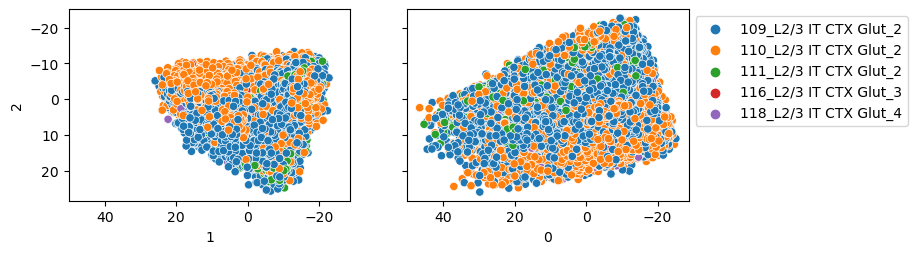


[Method: Harmony] correcting batch effect …
  Common genes: 914


2026-03-16 14:19:38,227 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-16 14:19:44,959 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-16 14:19:45,284 - harmonypy - INFO - Iteration 1 of 20
2026-03-16 14:20:02,197 - harmonypy - INFO - Converged after 1 iteration


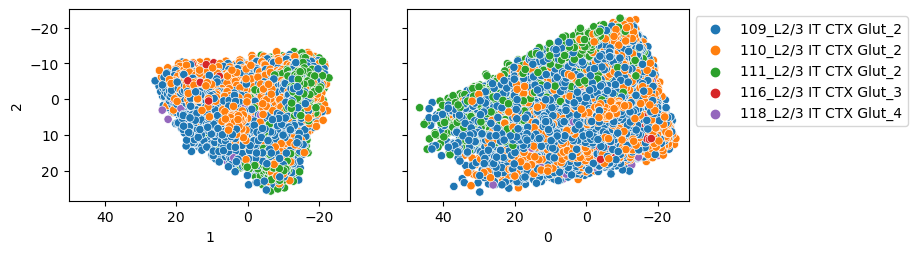


[Method: MNN Anchors] finding mutual nearest neighbors …
  Common genes: 914
  Found 50613 MNN anchors


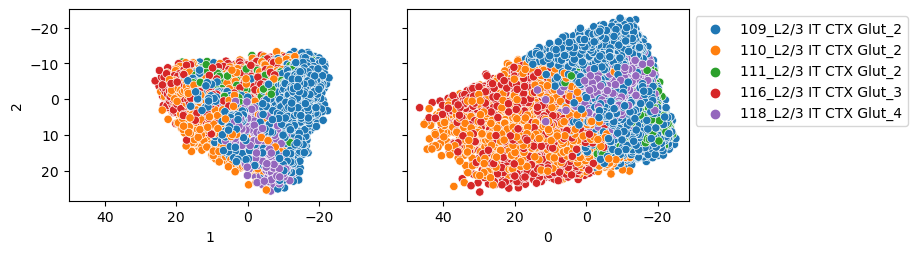

CPU times: user 1min 39s, sys: 1min 11s, total: 2min 51s
Wall time: 2min 12s


In [17]:
%%time

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(0)

for method in methods:
    labels, confs, query_labeled = transfer_labels(ref, query, label_key, method=method)
    
    cells = query_labeled.obs.index.values
    res = np.column_stack((cells,labels, confs))
    np.savetxt(os.path.join(ddir, f"L23_labels_gao25_to_Jorstad23_{method}.csv"), res, 
               fmt="%s",delimiter=",", header="label,conf", comments="")
    
    
    pcs  = query_labeled.obsm['X_pca']
    # isnr = query_labeled.obs['Age'].values=='P21'
    labels = query_labeled.obs[f'predicted_label_{method}'].values

    dfviz = pd.DataFrame(pcs[:,:3])
    # dfviz['isnr'] = isnr
    dfviz['type'] = labels


    fig, axs = plt.subplots(1,2,figsize=(2*4,1*4), sharex=True, sharey=True)
    ax = axs[0]
    sns.scatterplot(data=dfviz, x=1, y=2, hue='type', hue_order=hue_order, legend=False, ax=ax)
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_aspect('equal')

    ax = axs[1]
    sns.scatterplot(data=dfviz, x=0, y=1, hue='type', hue_order=hue_order, ax=ax)
    # ax.invert_xaxis()
    # ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.legend(bbox_to_anchor=(1,1))
    
    plt.show()



In [15]:
query_labeled.obs.columns

Index(['Class', 'CrossArea_subclass', 'CrossArea_cluster',
       'WithinArea_subclass', 'WithinArea_cluster', 'Source', 'Layer',
       'Location', 'Region', 'Subregion', 'nCount_RNA', 'nFeature_RNA',
       'assay_ontology_term_id', 'cell_type_ontology_term_id',
       'development_stage_ontology_term_id', 'disease_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id',
       'suspension_type', 'tissue_ontology_term_id', 'donor_id',
       'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease',
       'sex', 'tissue', 'self_reported_ethnicity', 'development_stage',
       'observation_joinid', 'n_genes_by_counts', 'total_counts',
       'total_counts_mt', 'pct_counts_mt', 'predicted_label_knn',
       'prediction_score_knn', 'high_confidence_knn',
       'predicted_label_harmony', 'prediction_score_harmony',
       'high_confidence_harmony', 'predicted_label_mnn',
       'prediction_score_mnn', 'high_confidence_mnn'],
      dtype='obj

In [16]:
!ls $ddir

atac_fragments
atac_l2fc_avc_p6to21.txt
atac_qs_avc_p6to21.txt
DAR_l23abc_cpm_tensor_250411.npy
DAR_l23abc_cpm_tensor.npy
DAR_l23abc_l2fc_250411.npy
DAR_l23abc_l2fc.npy
DAR_l23abc_qs_250411.npy
DAR_l23abc_qs.npy
DEG_l23abc_gene_list_250225.csv
DEG_l23abc_gene_list_250402.csv
DEG_l23abc_gene_list_250408.csv
DEG_l23abc_gene_list_250409.csv
DEG_l23abc_l2fc_250225.npy
DEG_l23abc_l2fc_250402.npy
DEG_l23abc_l2fc_250408.npy
DEG_l23abc_l2fc_250409.npy
DEG_l23abc_qs_250225.npy
DEG_l23abc_qs_250402.npy
DEG_l23abc_qs_250408.npy
DEG_l23abc_qs_250409.npy
easifish_sample1_res.csv
easifish_sample2_res.csv
easifish_sample3_res.csv
from_sal
from_sanjana
gene_sets_l23a_250423.csv
gene_sets_l23b_250423.csv
gene_sets_l23c_250423.csv
juyoun
L23_allmultiome_proc_P6toP21.h5ad
L23_allmultiome_proc_P6toP21_NRDR.h5ad
L23_allmultiome_raw.h5ad
L23_allmultiome_raw_pca_all.npy
L23_allmultiome_raw_pca_early.npy
L23_allmultiome_raw_pca.h5ad
L23_allmultiome_raw_pca_later.npy
L23_Allraw.h5ad
l23_alltime_hvgs_n4940.txt


In [18]:
# conf mat

In [19]:
f = os.path.join(ddir, 'L23_labels_gao25_to_Jorstad23_harmony.csv')
df = pd.read_csv(f)
df

,label,conf
AAACCCAGTGCCGTAC-9L8TX_200107_01_C10,110_L2/3 IT CTX Glut_2,0.930981
AAACGAAAGACTTCCA-9L8TX_200107_01_C10,111_L2/3 IT CTX Glut_2,0.470896
AAACGAATCGCTCTAC-9L8TX_200107_01_C10,109_L2/3 IT CTX Glut_2,0.462708
AAACGAATCTACTATC-9L8TX_200107_01_C10,111_L2/3 IT CTX Glut_2,0.543704
AAACGCTCAGGCACTC-9L8TX_200107_01_C10,110_L2/3 IT CTX Glut_2,0.797296
...,...,...
TGCTCCACAAGCCATT-12L8TX_191217_01_D04,109_L2/3 IT CTX Glut_2,0.510694
TTGCTGCCAGCAGGAT-12L8TX_191217_01_D04,110_L2/3 IT CTX Glut_2,0.421806
CCAATTTAGAGAGTTT-11L8TX_191217_01_C04,109_L2/3 IT CTX Glut_2,0.276640
GCGAGAAGTCTTGTCC-12L8TX_191217_01_D04,110_L2/3 IT CTX Glut_2,0.419173


In [23]:
meta_h = adata2.obs.join(df)

In [28]:
counts = meta_h.groupby(['WithinArea_cluster', 'label']).size()
counts = counts[counts!=0].unstack().fillna(0).astype(int)
counts

label,109_L2/3 IT CTX Glut_2,110_L2/3 IT CTX Glut_2,111_L2/3 IT CTX Glut_2,116_L2/3 IT CTX Glut_3,118_L2/3 IT CTX Glut_4
WithinArea_cluster,,,,,
L2/3 IT_1,693,73,0,0,15
L2/3 IT_2,10290,15305,9495,620,371
L2/3 IT_3,363,357,726,22,4
L2/3 IT_4,578,1291,1,125,19
L2/3 IT_5,8277,5052,55,27,395
L2/3 IT_6,412,117,35,0,24


In [43]:
freqs1 = counts/counts.sum()
freqs2 = (counts.T/counts.T.sum()).T

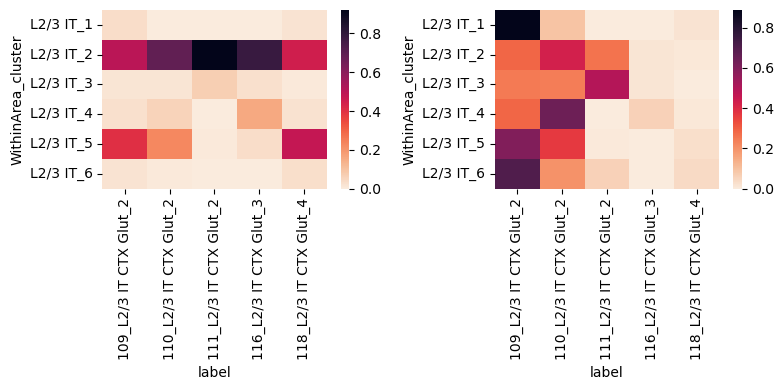

In [47]:
fig, axs = plt.subplots(1,2,figsize=(2*4,1*4))
ax = axs[0]
sns.heatmap(freqs1, cmap='rocket_r', ax=ax)

ax = axs[1]
sns.heatmap(freqs2, cmap='rocket_r', ax=ax)
fig.tight_layout()
plt.show()